In [1]:
from hgq.layers import QDense
from hgq.config import QuantizerConfig, QuantizerConfigScope
from keras.layers import Dense
from keras import Sequential
import numpy as np
from scipy.stats import wasserstein_distance
import polars as pl
from utils import add_project_root_to_sys_path
add_project_root_to_sys_path()
from neuralnet.quantization.hgq import hgq_quantize
from neuralnet.plotting import plot_variable_distribution_comparison

2026-07-06 19:00:58.027425: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-06 19:00:58.027820: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-06 19:00:58.065474: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-06 19:00:59.975803: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
fp_model  = Sequential([
    Dense(5, input_shape=(50,), activation='relu'),
    Dense(1, activation='sigmoid')
])
fp_model.summary()

/home/lucasbanunes/miniconda3/envs/neuralnet/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-06 19:01:03.010934: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │           255 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
weights_quantizer_config = QuantizerConfig(
    q_type="kif",
    place='weight',
    k0=True,
    i0=7,
    f0=15,
)
bias_quantizer_config = QuantizerConfig(
    q_type="kif",
    place='bias',
    k0=True,
    i0=7,
    f0=15,
)
ptq_model = hgq_quantize(
    fp_model,
    weights_quantizer_config,
    bias_quantizer_config
)
ptq_model.summary()

Model: "sequential_quantized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ q_dense (QDense)                │ (None, 5)              │         1,174 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_dense_1 (QDense)              │ (None, 1)              │            43 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (3.83 KB)

 Trainable params: 832 (3.25 KB)

 Non-trainable params: 385 (592.00 B)

In [4]:
for fp_layer, ptq_layer in zip(fp_model.layers, ptq_model.layers):
    if not (isinstance(fp_layer, Dense) and isinstance(ptq_layer, QDense)):
        raise TypeError(f"Expected Dense and QDense layers, got {type(fp_layer)} and {type(ptq_layer)}")
    fp_weights = fp_layer.get_weights()
    ptq_weights = ptq_layer.get_weights()

    if not np.all(fp_weights[0] == ptq_weights[0]):
        raise ValueError(f"Weight mismatch between fp_layer and ptq_layer: {fp_weights[0]} vs {ptq_weights[0]}")

    if not np.all(fp_weights[1] == ptq_weights[1]):
        raise ValueError(f"Weight mismatch between fp_layer and ptq_layer: {fp_weights[1]} vs {ptq_weights[1]}")

In [5]:
input_data = np.random.rand(1000000, 50).astype(np.float32)
fp_output = fp_model.predict(input_data, batch_size=int(2**15))
ptq_output = ptq_model.predict(input_data, batch_size=int(2**15))

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step


In [6]:
analysis_df = pl.DataFrame({'fp.output': fp_output.flatten(), 'ptq.output': ptq_output.flatten()})
analysis_df

fp.output,ptq.output
f32,f32
0.432904,0.404024
0.352571,0.351817
0.50457,0.527763
0.416915,0.418335
0.418188,0.435309
…,…
0.24786,0.23999
0.409237,0.431053
0.559148,0.592735


/home/lucasbanunes/workspaces/neuralnet/neuralnet/plotting.py:206: RuntimeWarning: divide by zero encountered in divide
  rel_diff = ((heights - ref_heights) / ref_heights) * 100
/home/lucasbanunes/workspaces/neuralnet/neuralnet/plotting.py:206: RuntimeWarning: invalid value encountered in divide
  rel_diff = ((heights - ref_heights) / ref_heights) * 100
/home/lucasbanunes/miniconda3/envs/neuralnet/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


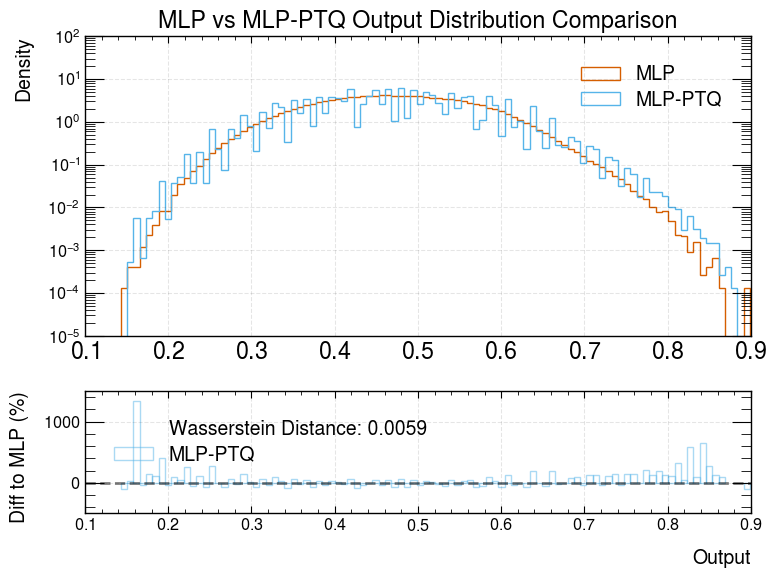

In [7]:
fig, _, bottom_ax = plot_variable_distribution_comparison(
    variable_label='Output',
    ref={'name': 'fp.output', 'label': 'MLP', 'color': 'C0'},
    to_compare=[
        {'name': 'ptq.output', 'label': 'MLP-PTQ', 'color': 'C1'},
    ],
    data=analysis_df,
    title='MLP vs MLP-PTQ Output Distribution Comparison',
    scale='log',
    hist_kwargs=dict(bins=100)
)
wass_distance = wasserstein_distance(fp_output.flatten(), ptq_output.flatten())
bottom_ax.plot([], [], ' ', label=f"Wasserstein Distance: {wass_distance:.4f}")
bottom_ax.legend()
fig.tight_layout()

In [26]:
analysis_df.select(pl.col('fp.output').quantile(0.1))

fp.output
f32
0.353894


In [22]:
distances = []
first_quartile_distances = []
last_quartile_distances = []
first_tenth_percentile_distances = []
last_tenth_percentile_distances = []
fp_first_quartile_limit, fp_third_quartile_limit, fp_tenth_percentile_limit, fp_ninetieth_percentile_limit = \
    np.quantile(fp_output.flatten(), [0.25, 0.75, 0.1, 0.9])
fp_output.flatten()
fp_first_quartile = fp_output[fp_output <= fp_first_quartile_limit]
fp_third_quartile = fp_output[fp_output >= fp_third_quartile_limit]
fp_tenth_percentile = fp_output[fp_output <= fp_tenth_percentile_limit]
fp_ninetieth_percentile = fp_output[fp_output >= fp_ninetieth_percentile_limit]
n_bits = list(range(1, 33)) 
for i, bits in enumerate(n_bits):
    ptq_model = hgq_quantize(
        fp_model,
        QuantizerConfig(
            q_type="kif",
            place='weight',
            k0=True,
            i0=bits,
            f0=bits,
        ),
        QuantizerConfig(
            q_type="kif",
            place='bias',
            k0=True,
            i0=bits,
            f0=bits,
        )
    )
    ptq_output = ptq_model.predict(input_data, batch_size=int(2**15)).flatten()
    wass_distance = wasserstein_distance(fp_output.flatten(), ptq_output.flatten())
    distances.append(wass_distance)
    ptq_first_quartile_limit, ptq_third_quartile_limit, ptq_tenth_percentile_limit, ptq_ninetieth_percentile_limit = \
        np.quantile(ptq_output.flatten(), [0.25, 0.75, 0.1, 0.9])
    ptq_first_quartile = ptq_output[ptq_output <= ptq_first_quartile_limit]
    first_quartile_distance = wasserstein_distance(fp_first_quartile, ptq_first_quartile)
    first_quartile_distances.append(first_quartile_distance)
    ptq_third_quartile = ptq_output[ptq_output >= ptq_third_quartile_limit]
    last_quartile_distance = wasserstein_distance(fp_third_quartile, ptq_third_quartile)
    last_quartile_distances.append(last_quartile_distance)
    ptq_tenth_percentile = ptq_output[ptq_output <= ptq_tenth_percentile_limit]
    first_tenth_percentile_distance = wasserstein_distance(fp_tenth_percentile, ptq_tenth_percentile)
    first_tenth_percentile_distances.append(first_tenth_percentile_distance)
    ptq_ninetieth_percentile = ptq_output[ptq_output >= ptq_ninetieth_percentile_limit]
    last_tenth_percentile_distance = wasserstein_distance(fp_ninetieth_percentile, ptq_ninetieth_percentile)
    last_tenth_percentile_distances.append(last_tenth_percentile_distance)
    print(f"{i} - Bits: {bits}")
    print(f"{i} - Wasserstein Distance: {wass_distance:.4f}")
    print(f"{i} - First Quartile Wasserstein Distance: {first_quartile_distance:.4f}")
    print(f"{i} - Last Quartile Wasserstein Distance: {last_quartile_distance:.4f}")
    print(f"{i} - First Tenth Percentile Wasserstein Distance: {first_tenth_percentile_distance:.4f}")
    print(f"{i} - Last Tenth Percentile Wasserstein Distance: {last_tenth_percentile_distance:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step
0 - Bits: 1
0 - Wasserstein Distance: 0.0421
0 - First Quartile Wasserstein Distance: 0.0109
0 - Last Quartile Wasserstein Distance: 0.0880
0 - First Tenth Percentile Wasserstein Distance: 0.0101
0 - Last Tenth Percentile Wasserstein Distance: 0.1122
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step
1 - Bits: 2
1 - Wasserstein Distance: 0.0475
1 - First Quartile Wasserstein Distance: 0.0428
1 - Last Quartile Wasserstein Distance: 0.0550
1 - First Tenth Percentile Wasserstein Distance: 0.0365
1 - Last Tenth Percentile Wasserstein Distance: 0.0601
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step
2 - Bits: 3
2 - Wasserstein Distance: 0.0224
2 - First Quartile Wasserstein Distance: 0.0090
2 - Last Quartile Wasserstein Distance: 0.0393
2 - First Tenth Percentile Wasserstein Distance: 0.0102
2 - Last Tenth Percentile Wasserstein Distance: 0.0553
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step
3 - Bits: 4
3 - Wasserstein Distance: 0.0217
3 - First Quartile Wasserstein Distance: 0

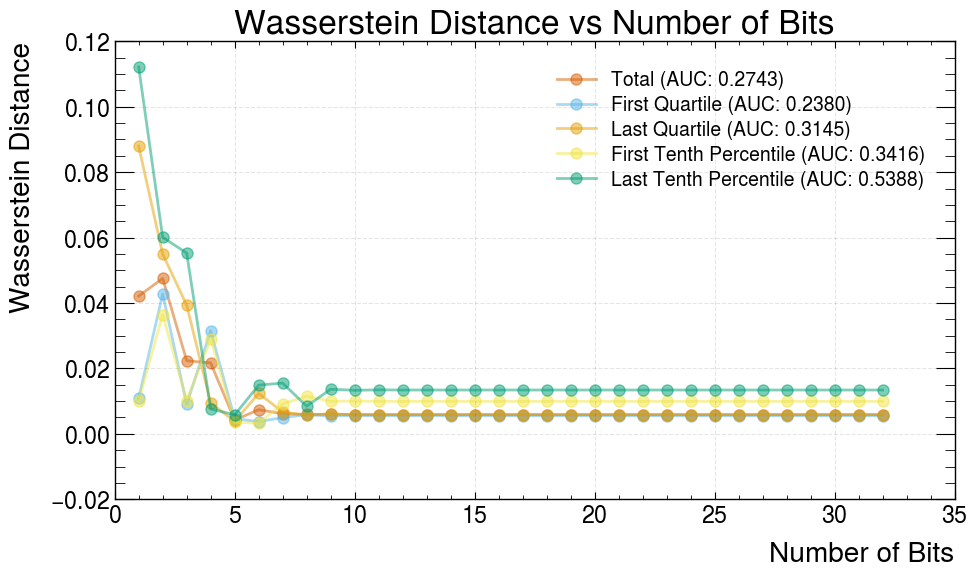

In [25]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid()
auc = np.trapezoid(distances, n_bits)
ax.plot(n_bits, distances, marker='o', label=f'Total (AUC: {auc:.4f})', alpha=0.5)
auc = np.trapezoid(first_quartile_distances, n_bits)
ax.plot(n_bits, first_quartile_distances, marker='o', label=f'First Quartile (AUC: {auc:.4f})', alpha=0.5)
auc = np.trapezoid(last_quartile_distances, n_bits)
ax.plot(n_bits, last_quartile_distances, marker='o', label=f'Last Quartile (AUC: {auc:.4f})', alpha=0.5)
auc = np.trapezoid(first_tenth_percentile_distances, n_bits)
ax.plot(n_bits, first_tenth_percentile_distances, marker='o', label=f'First Tenth Percentile (AUC: {auc:.4f})', alpha=0.5)
auc = np.trapezoid(last_tenth_percentile_distances, n_bits)
ax.plot(n_bits, last_tenth_percentile_distances, marker='o', label=f'Last Tenth Percentile (AUC: {auc:.4f})', alpha=0.5)
# ax.axhline(y=0, color='k', linestyle='--', alpha=0.5, label='Zero distance')
# median_distance = np.median(distances)
# ax.axhline(y=median_distance, linestyle='--', alpha=0.5, label=f'Median: {median_distance:.4f}')
# mean_distance = np.mean(distances)
# ax.axhline(y=mean_distance, linestyle='--', alpha=0.5, label=f'Mean: {mean_distance:.4f}')
ax.grid(linestyle="--", alpha=0.1, color="k")
ax.set_title("Wasserstein Distance vs Number of Bits")
ax.set_xlabel("Number of Bits")
ax.set_ylabel("Wasserstein Distance")
# ax.set_yscale('log')
ax.legend()
fig.tight_layout()